In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.tree import plot_tree
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.compose import ColumnTransformer,make_column_transformer,make_column_selector
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder



In [4]:
df=pd.read_csv("../Datasets/Housing.csv")

In [6]:
X=df.drop(columns=["price"])
Y=df["price"]

In [8]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=25)

In [12]:
one_hot_encoder=OneHotEncoder(drop="first",sparse_output=False).set_output(transform="pandas")
prms = make_column_transformer(
    (one_hot_encoder,make_column_selector(dtype_include="object")),
    remainder="passthrough",
    verbose_feature_names_out=False
)

In [13]:
prms=prms.set_output(transform="pandas")
x_train_prms=prms.fit_transform(X_train)
x_test_prms=prms.transform(X_test)

In [16]:
ddr=DecisionTreeRegressor(random_state=25,max_depth=2)
ddr=ddr.fit(x_train_prms,Y_train)
y_pred=ddr.predict(x_test_prms)

[Text(0.5, 0.8333333333333334, 'lotsize <= 5954.0\nsquared_error = 687134366.218\nsamples = 382\nvalue = 66491.209'),
 Text(0.25, 0.5, 'lotsize <= 4016.0\nsquared_error = 330775515.817\nsamples = 265\nvalue = 56522.264'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'squared_error = 226949327.881\nsamples = 156\nvalue = 50515.064'),
 Text(0.375, 0.16666666666666666, 'squared_error = 353807799.007\nsamples = 109\nvalue = 65119.725'),
 Text(0.75, 0.5, 'bathrms <= 1.5\nsquared_error = 759358921.033\nsamples = 117\nvalue = 89070.444'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'squared_error = 395420031.122\nsamples = 70\nvalue = 77612.143'),
 Text(0.875, 0.16666666666666666, 'squared_error = 814620096.851\nsamples = 47\nvalue = 106136.0')]

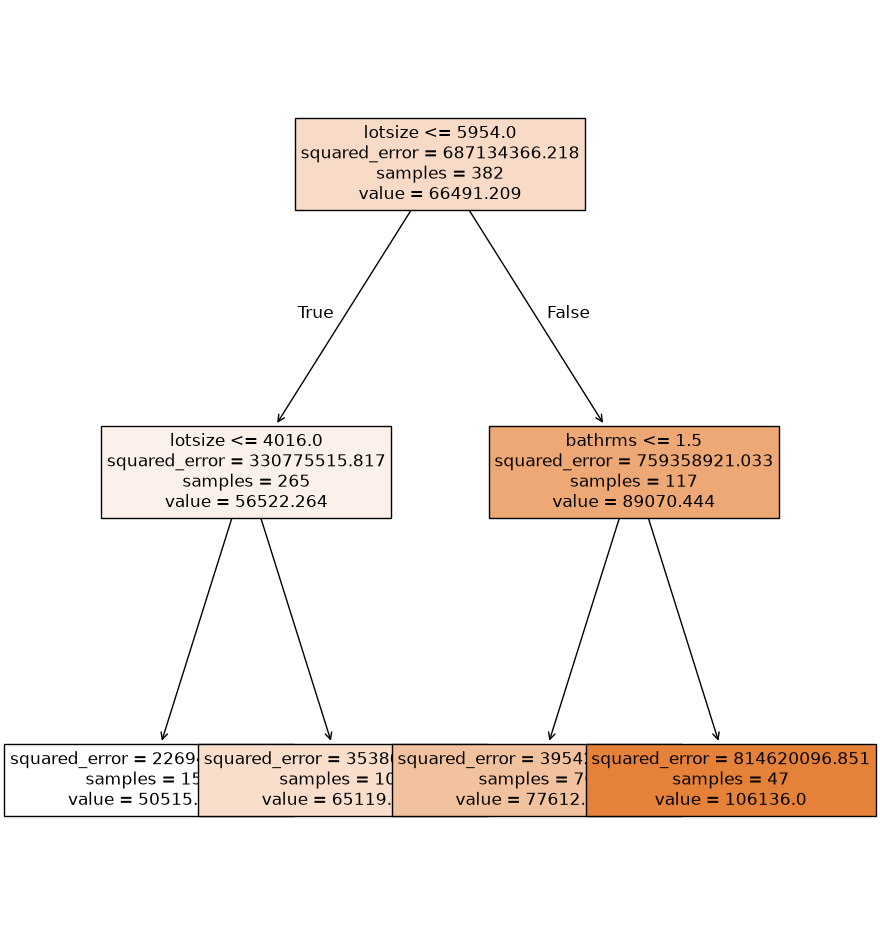

In [17]:
from matplotlib import pyplot as plt

plt.figure(figsize=(10,12))
plot_tree(
    ddr,
    feature_names=list(x_train_prms.columns),
    class_names=['0', '1'],
    filled=True,
    fontsize=12
)

In [25]:
print(Y_train.mean())
import numpy as np

66491.20942408378


In [33]:
print(np.mean((Y_train-Y_train.mean())**2))

687134366.2179216


In [29]:
Y_left=Y_train[X_train["lotsize"]<=5954]
print(Y_left.mean())

56522.264150943396


In [31]:
Y_right=Y_train[X_train["lotsize"]>5954]
print(Y_right.mean())

89070.44444444444


In [19]:
depths=[2,3,4,5,8,None]
leaves=[1,5,10,20,50]
splits=[2,5,10,20,50]
score=[]

for d in depths:
    for l in leaves:
        for s in splits:
            ddr=DecisionTreeRegressor(random_state=25,max_depth=d,min_samples_split=s,min_samples_leaf=l)
            ddr=ddr.fit(x_train_prms,Y_train)
            y_pred=ddr.predict(x_test_prms)
            score.append([d,l,s,r2_score(Y_test,y_pred)])


score_df=pd.DataFrame(score,columns=["depth","leaves","split","r2"]).sort_values("r2",ascending=False)
print(score_df.head())





     depth  leaves  split        r2
103    8.0       1     20  0.520188
108    8.0       5     20  0.517948
128    NaN       1     20  0.516177
78     5.0       1     20  0.514985
133    NaN       5     20  0.513971


In [23]:
best_model=DecisionTreeRegressor(random_state=25,max_depth=8,min_samples_split=20,min_samples_leaf=1)
x_trms=prms.fit_transform(X)
best_model.fit(x_trms, Y)
# what is importance
df_imp=pd.DataFrame({'feature':x_trms.columns,"importance":best_model.feature_importances_}).sort_values(by="importance",ascending=False)
print(df_imp)

         feature  importance
6        lotsize    0.509114
8        bathrms    0.214331
4      airco_yes    0.095655
10      garagepl    0.042990
2   fullbase_yes    0.038394
9        stories    0.033116
3      gashw_yes    0.025585
1    recroom_yes    0.016801
7       bedrooms    0.013276
5   prefarea_yes    0.010738
0   driveway_yes    0.000000


In [34]:
import seaborn as sns

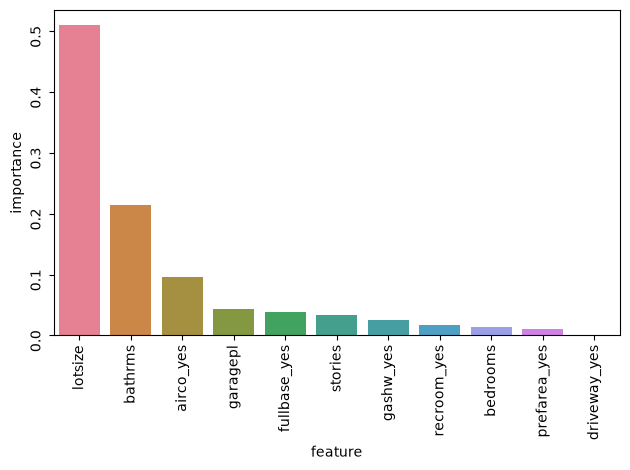

In [39]:
plt.Figure(figsize=(10,12))
sns.barplot(data=df_imp,x="feature",y="importance",hue="feature")
plt.yticks(rotation=90)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()